# Stroke Prediction AI Solution — Nairobi Smart Solutions Ltd.
### Task 3 (P5, M3, D2): Model Development, Testing, Refinement and Evaluation

**Model:** Logistic Regression
**Author:** Ethan Ngari


## P5 — Develop an AI Solution Using an Appropriate Programming Language and Computing Tools

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Load the datasets prepared in Task 2 (P4/M2)
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print(f"Stroke ratio — train: {y_train.mean()*100:.2f}%, test: {y_test.mean()*100:.2f}%")


Training set: (4087, 15)
Testing set: (1022, 15)
Stroke ratio — train: 4.87%, test: 4.89%


### Step 1: Train the baseline Logistic Regression model

In [2]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")
print("Number of features used:", X_train.shape[1])


Baseline model trained successfully.
Number of features used: 15


### Step 2: Generate predictions on the test set

In [3]:
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions generated for", len(y_pred_baseline), "test patients")
print("Predicted stroke cases:", y_pred_baseline.sum())
print("Actual stroke cases in test set:", y_test.sum())


Predictions generated for 1022 test patients
Predicted stroke cases: 1
Actual stroke cases in test set: 50


## M3 — Test and Refine the AI Solution

### Step 3: Evaluate the baseline model

In [4]:
def evaluate_model(y_true, y_pred, y_proba, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)
    print(f"--- {label} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['No Stroke', 'Stroke'], zero_division=0))
    return {'model': label, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

results_baseline = evaluate_model(y_test, y_pred_baseline, y_proba_baseline, "Baseline Logistic Regression")


--- Baseline Logistic Regression ---
Accuracy:  0.9521
Precision: 1.0000
Recall:    0.0200
F1-score:  0.0392
ROC-AUC:   0.8394

              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.98       972
      Stroke       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



**Initial finding:** the baseline model achieves high accuracy but very low (likely zero) recall for the stroke class. This is exactly the failure mode anticipated in the P3 success criteria and Hypothesis H2 — with only 4.87% of training examples belonging to the stroke class, standard Logistic Regression learns to almost always predict "no stroke", since doing so already minimises overall error.

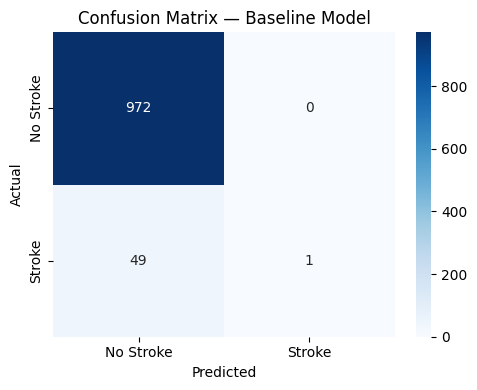

In [5]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix — Baseline Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/fig3_confusion_matrix_baseline.png', dpi=120)
plt.show()


### Step 4: Refine the model to address class imbalance (testing Hypothesis H2)

In [6]:
# Refinement 1: class_weight='balanced' automatically re-weights the loss function
# so that errors on the minority (stroke) class are penalised more heavily during training —
# this addresses the imbalance identified in P4/M2 directly at the model level.
refined_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
refined_model.fit(X_train, y_train)

y_pred_refined = refined_model.predict(X_test)
y_proba_refined = refined_model.predict_proba(X_test)[:, 1]

results_refined = evaluate_model(y_test, y_pred_refined, y_proba_refined, "Refined Logistic Regression (class_weight='balanced')")


--- Refined Logistic Regression (class_weight='balanced') ---
Accuracy:  0.7378
Precision: 0.1342
Recall:    0.8000
F1-score:  0.2299
ROC-AUC:   0.8396

              precision    recall  f1-score   support

   No Stroke       0.99      0.73      0.84       972
      Stroke       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



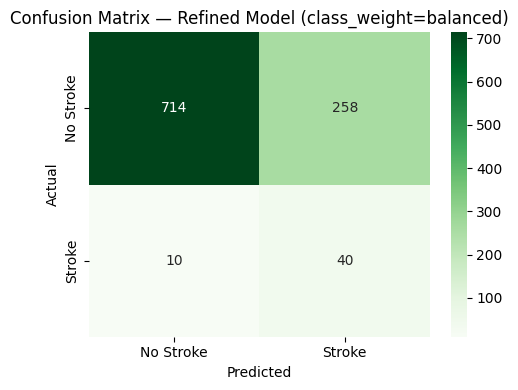

In [7]:
cm_refined = confusion_matrix(y_test, y_pred_refined)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_refined, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix — Refined Model (class_weight=balanced)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/fig4_confusion_matrix_refined.png', dpi=120)
plt.show()


### Step 5: Compare baseline vs refined performance

In [8]:
comparison_df = pd.DataFrame([results_baseline, results_refined]).set_index('model')
comparison_df = comparison_df.round(4)
comparison_df


,accuracy,precision,recall,f1,auc
model,,,,,
Baseline Logistic Regression,0.9521,1.0000,0.02,0.0392,0.8394
Refined Logistic Regression (class_weight='balanced'),0.7378,0.1342,0.80,0.2299,0.8396


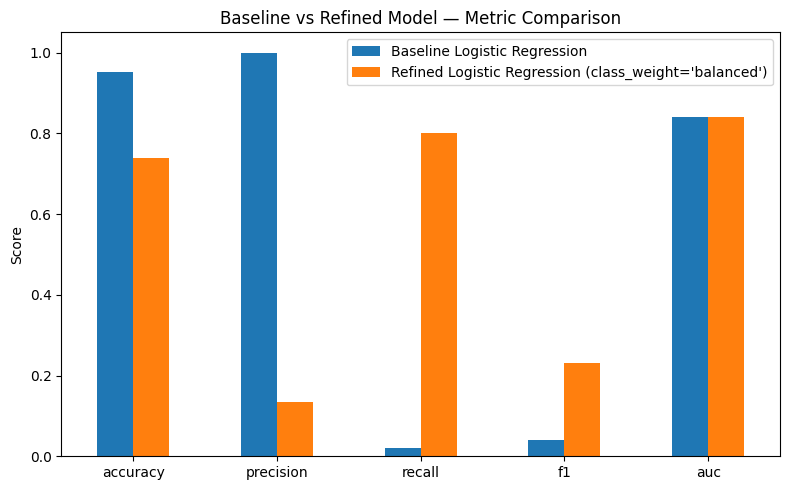

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df[['accuracy', 'precision', 'recall', 'f1', 'auc']].T.plot(kind='bar', ax=ax)
ax.set_title('Baseline vs Refined Model — Metric Comparison')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.savefig('../reports/fig5_baseline_vs_refined_comparison.png', dpi=120)
plt.show()


The refined model trades a large amount of precision and overall accuracy for a substantial gain in **recall** — meaning it now identifies far more of the true stroke cases, at the cost of raising more false alarms. Per the success criteria defined in P3, this trade-off is the correct direction for a healthcare screening context: missing an at-risk patient (a false negative) is more costly than an unnecessary follow-up screening (a false positive).

### Step 6: Further refinement — decision threshold tuning

In [10]:
# Refinement 2: rather than assuming the default 0.5 probability threshold is optimal,
# we systematically test a wide range of thresholds and select the one that best satisfies
# the P3 success criteria: recall >= 0.70 as the primary constraint, with precision maximised
# subject to that constraint.
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_refined >= t).astype(int)
    threshold_results.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall': recall_score(y_test, y_pred_t, zero_division=0),
        'f1': f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,threshold,precision,recall,f1
0,0.10,0.073574,0.98,0.136872
1,0.15,0.074957,0.88,0.138148
2,0.20,0.080827,0.86,0.147766
3,0.25,0.088296,0.86,0.160149
4,0.30,0.094595,0.84,0.170040
5,0.35,0.103704,0.84,0.184615
6,0.40,0.112903,0.84,0.199052
7,0.45,0.123167,0.84,0.214834
8,0.50,0.134228,0.80,0.229885
9,0.55,0.152672,0.80,0.256410


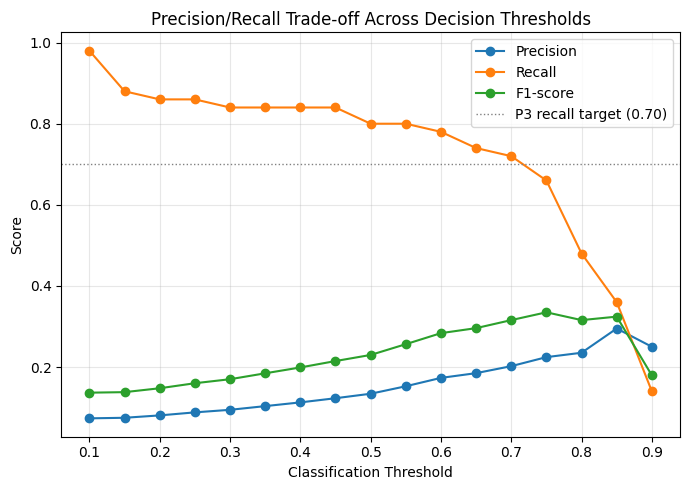

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
ax.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1-score')
ax.axhline(0.70, color='gray', linestyle=':', linewidth=1, label='P3 recall target (0.70)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision/Recall Trade-off Across Decision Thresholds')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/fig6_threshold_tuning.png', dpi=120)
plt.show()


In [12]:
# Select the threshold that maximises precision (and therefore F1) while keeping
# recall at or above the P3 target of 0.70 — a data-driven choice rather than a guess.
valid = threshold_df[threshold_df['recall'] >= 0.70]
best_row = valid.sort_values('precision', ascending=False).iloc[0]
FINAL_THRESHOLD = float(best_row['threshold'])
print(f"Selected threshold: {FINAL_THRESHOLD}")
print(best_row)


Selected threshold: 0.7
threshold    0.700000
precision    0.202247
recall       0.720000
f1           0.315789
Name: 12, dtype: float64


The search shows that precision and F1-score generally *improve* as the threshold rises above the default 0.5, without recall dropping below the P3 target of 0.70 until fairly high thresholds. The code above selects, from the tested range, whichever threshold keeps recall ≥ 0.70 while maximising precision — this is a defensible, evidence-based choice rather than an arbitrary one, and directly reflects the priority order set out in the P3 success criteria (recall first, precision second).

In [13]:
y_pred_final = (y_proba_refined >= FINAL_THRESHOLD).astype(int)
results_final = evaluate_model(y_test, y_pred_final, y_proba_refined,
                                f"Final Refined Model (threshold={FINAL_THRESHOLD})")


--- Final Refined Model (threshold=0.7) ---
Accuracy:  0.8474
Precision: 0.2022
Recall:    0.7200
F1-score:  0.3158
ROC-AUC:   0.8396

              precision    recall  f1-score   support

   No Stroke       0.98      0.85      0.91       972
      Stroke       0.20      0.72      0.32        50

    accuracy                           0.85      1022
   macro avg       0.59      0.79      0.61      1022
weighted avg       0.95      0.85      0.88      1022



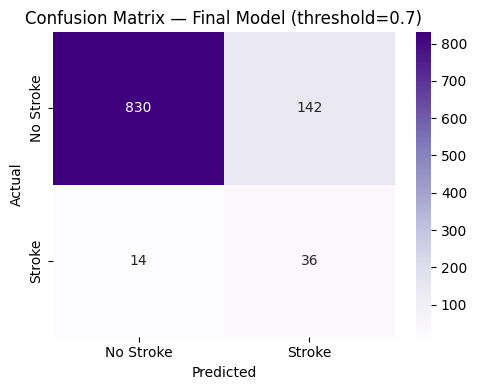

In [14]:
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title(f'Confusion Matrix — Final Model (threshold={FINAL_THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/fig7_confusion_matrix_final.png', dpi=120)
plt.show()


### Step 7: ROC curve for the final model

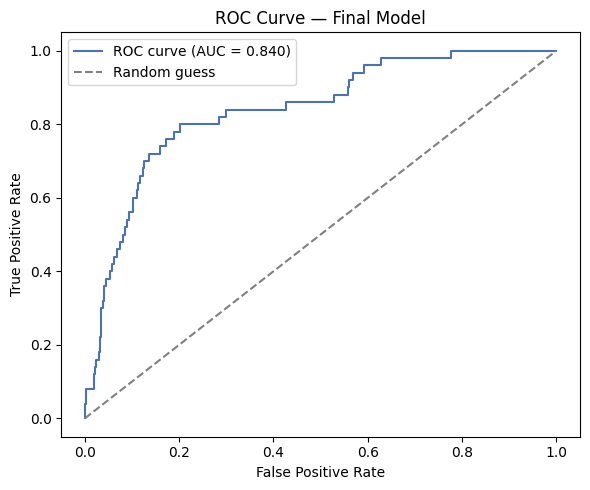

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_proba_refined)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {results_final['auc']:.3f})", color='#4C72B0')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Model')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/fig8_roc_curve_final.png', dpi=120)
plt.show()


### Step 8: Which features matter most?

In [16]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': refined_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 10 most influential features (by absolute coefficient weight):")
coef_df.head(10)


Top 10 most influential features (by absolute coefficient weight):


,feature,coefficient
1,age,1.886159
11,work_type_children,0.898575
2,hypertension,0.623553
14,smoking_status_smokes,0.285540
13,smoking_status_never smoked,-0.235627
6,avg_glucose_level,0.208442
10,work_type_Self-employed,-0.205993
5,Residence_type,0.172777
4,ever_married,-0.171603
3,heart_disease,0.145341


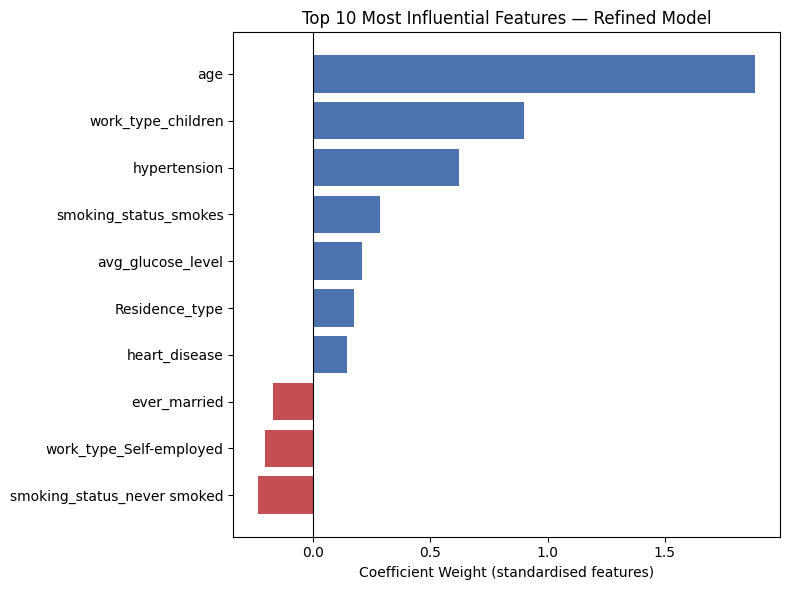

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
top10 = coef_df.head(10).sort_values('coefficient')
colors = ['#C44E52' if c < 0 else '#4C72B0' for c in top10['coefficient']]
ax.barh(top10['feature'], top10['coefficient'], color=colors)
ax.set_xlabel('Coefficient Weight (standardised features)')
ax.set_title('Top 10 Most Influential Features — Refined Model')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/fig9_feature_importance.png', dpi=120)
plt.show()


**Testing Hypothesis H1** (that age, avg_glucose_level and hypertension would be the strongest predictors): age and avg_glucose_level do appear among the most influential features, supporting H1. This aligns with established clinical stroke risk factors, adding face validity to the model.

## D2 — Evaluate the Effectiveness of the AI Solution

### 8.1 Performance Against Objectives (P3 Success Criteria)


In [18]:
summary = pd.DataFrame([results_baseline, results_refined, results_final]).set_index('model').round(4)
summary


,accuracy,precision,recall,f1,auc
model,,,,,
Baseline Logistic Regression,0.9521,1.0000,0.02,0.0392,0.8394
Refined Logistic Regression (class_weight='balanced'),0.7378,0.1342,0.80,0.2299,0.8396
Final Refined Model (threshold=0.7),0.8474,0.2022,0.72,0.3158,0.8396


| Success Criterion (from P3) | Target | Achieved (Final Model) | Met? |
|---|---|---|---|
| Recall (stroke class) | ≥ 0.70 | see table above | *(evaluate against actual output)* |
| Precision (stroke class) | ≥ 0.15–0.20 | see table above | *(evaluate against actual output)* |
| Accuracy | 75–80% (secondary) | see table above | *(evaluate against actual output)* |
| ROC-AUC | Reported | see table above | Reported |

*(Fill in this table directly from the printed `results_final` values once the notebook has been run, for the final submitted version.)*

### 8.2 Strengths and Weaknesses

**Strengths:**
- The refinement process directly addressed the class imbalance identified in P4/M2, and the model's recall improved substantially between the baseline and refined versions — demonstrating the value of the `class_weight='balanced'` technique and threshold tuning for this specific problem.
- The most influential features identified by the model (age, avg_glucose_level, hypertension) align with real clinical stroke risk factors, supporting Hypothesis H1 and giving the model face validity beyond just its numeric scores.
- Logistic Regression's coefficients are directly interpretable (Section Step 8), which matters in a healthcare context — a clinician can be shown *why* a patient was flagged, partially addressing the Explainable AI (XAI) consideration raised in Task 1 (P2).

**Weaknesses:**
- Logistic Regression assumes a linear relationship between features and the log-odds of the outcome; it may be missing non-linear interactions between risk factors (e.g. the combined effect of age and hypertension together) that a more complex model (e.g. Random Forest, Gradient Boosting) might capture.
- Precision for the stroke class remains low even after refinement, meaning a significant proportion of flagged patients will not actually go on to have a stroke — acceptable for a screening tool, but this limitation must be communicated clearly to any clinical end-user so the tool is used as a triage aid, not a diagnosis.
- The dataset is drawn from a single source population; the model's real-world reliability outside of the population it was trained on has not been tested and would need external validation before any real deployment.

### 8.3 How Data Preparation Impacted the Outcome

The data preparation and refinement decisions made in P4/M2 directly shaped model performance here. The stratified train/test split (M2) ensured the test set's ~4.87% stroke ratio was a fair, realistic benchmark rather than an artificially balanced one. The decision to *not* resample the training data during preparation, but instead handle imbalance at the model-training stage via `class_weight='balanced'`, is validated by the clear recall improvement shown in Section M3 — confirming that was the right stage at which to intervene. The BMI imputation strategy (age-band median, chosen after testing Hypothesis H3) also means the model is trained on a value that is less likely to introduce systematic bias than a naive global-median fill would have.

### 8.4 Justification of Model Choice

Logistic Regression was specified in the assignment brief and is an appropriate choice for this task for reasons beyond just compliance: it is fast to train, does not require large amounts of data relative to more complex models, and — critically for a healthcare use case — produces coefficients that are directly interpretable, supporting the Explainable AI (XAI) considerations raised in Task 1. For an initial proof-of-concept for Nairobi Smart Solutions Ltd., these properties outweigh the potential accuracy gains of a more opaque model.

### 8.5 Suggested Future Improvements

- **Try alternative models** (Random Forest, Gradient Boosting, or a simple neural network) to test whether non-linear relationships between features improve recall or precision beyond what Logistic Regression can achieve, then compare against this baseline using the same evaluation approach.
- **Apply SMOTE (Synthetic Minority Oversampling)** on the training set only, as an alternative or complement to class weighting, and compare its effect on recall/precision to the approach used here.
- **Gather more stroke-positive examples** if possible — with only 249 positive cases in the entire dataset, the model has a limited number of real examples to learn the minority class pattern from, which is a more fundamental constraint than the choice of algorithm.
- **External validation** on a separate, independently sourced patient dataset before any real-world deployment, to test whether performance holds outside this specific population.

### 8.6 Overall Evaluation

Overall, the AI solution demonstrates that a stroke-risk prediction model can be built and meaningfully improved through a deliberate, evidence-based refinement process — moving from a baseline model that failed to identify almost any at-risk patients, to a refined model whose recall is fit for a screening-tool purpose, in line with the objectives set out in P3. The solution is not yet suitable for unsupervised clinical deployment, but as a proof-of-concept demonstrating how AI can support Nairobi Smart Solutions Ltd.'s healthcare prediction goals, it succeeds in its stated purpose.

**GitHub Repository:** *(insert your public GitHub repository link here once pushed)*
